## 🚚 Multi-objective Maintenance Crew Routing and Scheduling with **pymoo**

### 🎯 Educational Notebook

This notebook presents a realistic maintenance logistics optimization problem.

A utility company operates **8 geographically distributed substations**. One mobile maintenance crew must visit the sites over **4 working days**.

Unlike the previous simplified example, the objectives now **depend on the maintenance schedule**, creating a genuine Pareto trade-off.

The notebook demonstrates:

- ⚖️ Preference-based weighted optimization
- 📈 Pareto optimization using NSGA-II
- Visualization of the Pareto front



## 📖 Problem Formulation

### Decision Variable

Each variable represents the **maintenance day** assigned to one site.

$x_i \in \{1,2,3,4\}$

where $x_i=d$ means site $i$ is maintained on day $d$.

### Parameters

- $C_i^m$ : maintenance cost
- $C_i^{tr}$ : travel cost
- $R_{id}$ : failure risk if maintained on day $d$
- $h_i$ : maintenance duration (hours)
- $H_d$ : available crew-hours

### Objective 1

Minimize logistics cost

$$
f_1=
\sum_i
(C_i^m+C_i^{tr}\alpha_{x_i})
+
P_{OT}
$$

where $\alpha_{x_i}$ is a day-dependent travel multiplier and
$P_{OT}$ is an overtime penalty.

### Objective 2

Minimize operational risk

$$
f_2=
\sum_iR_{i,x_i}
$$

### Constraints

Daily crew-hours cannot exceed capacity.

A quadratic penalty is added whenever

$$
\sum_i h_i x_{id}>H_d
$$

This soft-constraint approach is commonly used with evolutionary algorithms.

In [12]:
# !pip install pymoo matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt

from pymoo.core.problem import ElementwiseProblem
from pymoo.optimize import minimize
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

np.random.seed(42)

n_sites=8
n_days=4

maintenance=np.random.randint(180,320,n_sites)
travel=np.random.randint(50,180,n_sites)
hours=np.random.randint(2,5,n_sites)

capacity=np.array([8,8,8,8])

day_multiplier=np.array([1.0,1.1,1.25,1.45])

risk=np.vstack([
    np.linspace(np.random.randint(60,120),
                np.random.randint(350,650),
                n_days)
    for _ in range(n_sites)
])

def evaluate_schedule(schedule):
    idx=schedule.astype(int)-1

    logistics=0
    operational=0
    overtime_penalty=0

    load=np.zeros(n_days)

    for i,d in enumerate(idx):
        logistics += (maintenance[i]+travel[i])*day_multiplier[d]
        operational += risk[i,d]
        load[d]+=hours[i]

    for d in range(n_days):
        overtime=max(0,load[d]-capacity[d])
        overtime_penalty += 300*overtime**2

    logistics += overtime_penalty

    return logistics, operational

### ⚖️ Approach 1 — Preference-based Weighted Sum

In [ ]:
class WeightedProblem(ElementwiseProblem):

    def __init__(self,w_cost=0.45,w_risk=0.55):
        self.wc=w_cost
        self.wr=w_risk
        super().__init__(
            n_var=n_sites,
            n_obj=1,
            xl=np.ones(n_sites),
            xu=np.full(n_sites,n_days),
            vtype=int)

    def _evaluate(self,x,out,*args,**kwargs):
        cost,riskv=evaluate_schedule(x)
        out["F"]=self.wc*cost+self.wr*riskv

problem=WeightedProblem()

algorithm=GA(
    pop_size=120,
    sampling=IntegerRandomSampling(),
    crossover=SBX(prob=0.9,eta=20),
    mutation=PM(eta=20)
)

res=minimize(problem,algorithm,("n_gen",200),seed=1,verbose=False)

c,r=evaluate_schedule(res.X)
print("Recommended schedule:",res.X.astype(int))
print("Logistics cost:",round(c,2))
print("Operational risk:",round(r,2))

Recommended schedule: [3 2 1 1 2 3 2 1]
Logistics cost: 3378.6
Operational risk: 1506.67


### 📈 Approach 2 — Pareto Optimization using NSGA-II

Pareto solutions: 150
Unique objective pairs: 28


c:\Users\alaa.rashwan\.conda\envs\agents\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


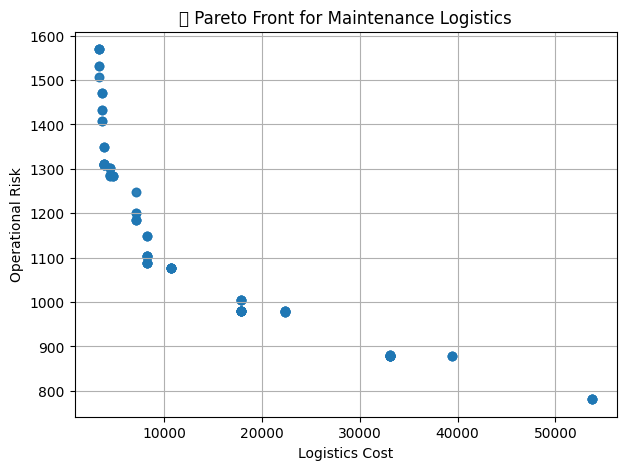

In [ ]:
class ParetoProblem(ElementwiseProblem):

    def __init__(self):
        super().__init__(
            n_var=n_sites,
            n_obj=2,
            xl=np.ones(n_sites),
            xu=np.full(n_sites,n_days),
            vtype=int)

    def _evaluate(self,x,out,*args,**kwargs):
        out["F"]=list(evaluate_schedule(x))

problem=ParetoProblem()

algorithm=NSGA2(
    pop_size=150,
    sampling=IntegerRandomSampling(),
    crossover=SBX(prob=0.9,eta=20),
    mutation=PM(eta=20)
)

res=minimize(problem,algorithm,("n_gen",300),seed=3,verbose=False)

print("Pareto solutions:",len(res.F))
print("Unique objective pairs:",len(np.unique(np.round(res.F,3),axis=0)))

plt.figure(figsize=(7,5))
plt.scatter(res.F[:,0],res.F[:,1],alpha=0.75)
plt.xlabel("Logistics Cost")
plt.ylabel("Operational Risk")
plt.title("📈 Pareto Front for Maintenance Logistics")
plt.grid(True)
plt.show()